# Demo 1. DIALS in Jupyter

**Companion to slide 7 of *Teaching Crystallographic Computing with Computational Notebooks*.**
27th Congress and General Assembly of the IUCr, Calgary, Alberta, 2026 August 17.

Blaine Mooers, PhD. Department of Biochemistry and Physiology, University of Oklahoma Health Campus.
blaine-mooers@ou.edu

## What this demonstration covers

1. Importing diffraction images.
2. Spot finding and indexing.
3. Refinement and integration.
4. Visualizing reciprocal space.

## The idea behind the demonstration

DIALS is a framework rather than a monolithic integration program, so every step of
data reduction is a separate dispatcher that reads and writes files you can inspect.
That design is a gift to teaching. Students watch one operation at a time, look at what
it produced, and only then move on. The pipeline stops being a single opaque button.

Each dispatcher also has a Python counterpart. The notebook uses the shell form for the
workflow and the Python form for the inspection, so students see both faces of the same
library.

## Data

Zenodo record [3752540](https://doi.org/10.5281/zenodo.3752540) holds 686 CBF frames of
SARS-CoV-2 main protease bound to 2-methyl-1-tetralone. The frames were collected on
beamline P11 at PETRA III with 0.2 degrees per frame, a 40 ms exposure, a wavelength of
1.033214 angstroms, and the detector at 200 mm. The deposited structure is PDB entry 6YNQ.

Each frame is 6.2 MB, so the full sweep is 6.2 GB. We take a wedge instead.

## How to run this in front of a class

The conda install of DIALS takes ten to fifteen minutes on a cold Colab virtual machine.
Run this notebook once the night before, save a copy to your Google Drive, and open that
copy in class. Then only the workflow cells need to run live.

Cells marked **PREBAKE** are the slow ones.

If a cell stalls, use *Runtime > Restart runtime* and rerun from the top of the section.

## Plan B when internet access is risky

If the internet is unavailable or unreliable, install DIALS in advance and run this same notebook in Jupyter Notebook or Jupyter Lab.
You will need to install dials in a conda env and then create a Jupyter kernel.
Note that reciprocalspaceship depends on setuptools.

```bash
conda create -n dials-env -c conda-forge dials gemmi reciprocalspaceship matplotlib \ 
  pandas jupyter setuptools
conda activate dials-env 
python -m ipykernel install --user --name dials-env --display-name "conda py3.14 (DIALS)"
ls -ltr ~/Library/Jupyter/kernels
```

## 1. Where are we?

Colab hands you a fresh Linux virtual machine for every session. The machine disappears
when you disconnect, so anything worth keeping belongs on Google Drive or on your laptop.

In [1]:
# LOCAL
#
# Silence the pydevd file-validation warning that Colab prints on import.
# This must be set before anything else imports.
import os

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

import platform
import shutil
import sys

print("Python   :", sys.version.split()[0])
print("Platform :", platform.platform())
try:
    total, used, free = shutil.disk_usage("/content")
    root = "/content"
except FileNotFoundError:
    total, used, free = shutil.disk_usage(".")
    root = os.getcwd()
print(f"Disk on {root}: {free / 1e9:.1f} GB free of {total / 1e9:.1f} GB")

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
print("Running in Colab:", IN_COLAB)

Python   : 3.14.6
Platform : macOS-26.6.1-arm64-arm-64bit-Mach-O
Disk on /Users/blaine/3285CCinJNiucr26/demos: 43.8 GB free of 3996.3 GB
Running in Colab: False


In [2]:
# LOCAL
#
# Make a clean working directory and move into it.
import pathlib

WORK = pathlib.Path("/content/mpro_dials" if IN_COLAB else "./mpro_dials").resolve()
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("Working in", WORK)

Working in /Users/blaine/3285CCinJNiucr26/demos/mpro_dials


## 2. Install DIALS

**PREBAKE.** DIALS ships on conda-forge together with cctbx, dxtbx, and scitbx. The
cleanest route onto Colab is [condacolab](https://github.com/conda-incubator/condacolab),
which swaps the system Python for a Mambaforge install and then restarts the kernel.

The kernel restart in the next cell is expected. Do not panic and do not rerun the cell.

In [ ]:
# PREBAKE. Installs condacolab and restarts the kernel.
if IN_COLAB:
    !pip -q install condacolab
    import condacolab

    condacolab.install()  # The kernel restarts here. This is normal.
else:
    print("Not in Colab. Install DIALS with: conda create -n dials -c conda-forge dials")

In [ ]:
# PREBAKE. Run this only after the kernel has restarted.
#
# condacolab writes a pinned file that locks python and python_abi.
# Conda-forge resolves the DIALS stack against a different minor version,
# so wipe the pin and let the solver move freely. This is safe inside a
# throwaway Colab virtual machine.
!rm -f /usr/local/conda-meta/pinned
!mamba install -y -q -c conda-forge dials gemmi reciprocalspaceship matplotlib pandas

In [3]:
# LOCAL
# Smoke test. dials.version prints the build identifier.
!dials.version

DIALS 3.30
Python 3.14.6
Installed in: /opt/homebrew/Caskroom/miniconda/base/envs/dials-env/lib/python3.14/site-packages/dials


In [4]:
# LOCAL
!which dials.import dials.find_spots dials.index dials.refine dials.integrate dials.scale

/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.import
/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.find_spots
/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.index
/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.refine
/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.integrate
/opt/homebrew/Caskroom/miniconda/base/envs/dials-env/bin/dials.scale


### Re-establish the session after the restart

The kernel restart wiped every variable. This cell rebuilds the three names the rest of
the notebook depends on. Run it once after the DIALS install finishes.

In [4]:
import os
import pathlib
import sys

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
WORK = pathlib.Path("/content/mpro_dials" if IN_COLAB else "./mpro_dials").resolve()
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("Working in", WORK)

Working in /Users/blaine/3285CCinJNiucr26/demos/mpro_dials/mpro_dials


## 3. Fetch a wedge of frames from Zenodo

Sixty frames span twelve degrees of rotation. That is enough to find spots, index, and
integrate a partial dataset, and it downloads in a few minutes rather than an hour.
Raise `N_FRAMES` when you want better completeness and you have the time to wait.

In [5]:
# LOCAL
import concurrent.futures
import urllib.request

RECORD = "3752540"
STEM = "l6p17_09_001"
N_FRAMES = 60  # 60 frames x 0.2 deg = 12 degrees of rotation.
FRAME_DIR = WORK / "frames"
FRAME_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def frame_url(n: int) -> str:
    """Return the direct download URL for frame n of the Zenodo record."""
    return f"https://zenodo.org/records/{RECORD}/files/{STEM}_{n:05d}.cbf?download=1"


def fetch_frame(n: int) -> str:
    """Download frame n unless it is already on disk. Return a status string."""
    dest = FRAME_DIR / f"{STEM}_{n:05d}.cbf"
    # A cached frame is accepted only if it is within 0.5 percent of the
    # largest frame already on disk. This catches truncated downloads that
    # sneak past a fixed byte threshold, because Zenodo can drop a
    # connection after megabytes of data have already streamed to disk.
    peers = [p.stat().st_size for p in FRAME_DIR.glob("*.cbf")]
    peak = max(peers) if peers else 0
    if dest.exists() and dest.stat().st_size >= 0.995 * peak and peak > 0:
        return f"cached  {dest.name}"
    if dest.exists():
        dest.unlink()  # remove the partial file before retrying
    urllib.request.urlretrieve(frame_url(n), dest)
    return f"fetched {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)"

# If the job fails, reduce the max_workers to 2 and rerun this cell.
# The correctly downloaded files will not be overwritten.
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as pool:
    for msg in pool.map(fetch_frame, range(1, N_FRAMES + 1)):
        print(msg)

cached  l6p17_09_001_00001.cbf
cached  l6p17_09_001_00002.cbf
cached  l6p17_09_001_00003.cbf
cached  l6p17_09_001_00004.cbf
cached  l6p17_09_001_00005.cbf
cached  l6p17_09_001_00006.cbf
cached  l6p17_09_001_00007.cbf
cached  l6p17_09_001_00008.cbf
cached  l6p17_09_001_00009.cbf
cached  l6p17_09_001_00010.cbf
cached  l6p17_09_001_00011.cbf
cached  l6p17_09_001_00012.cbf
cached  l6p17_09_001_00013.cbf
cached  l6p17_09_001_00014.cbf
cached  l6p17_09_001_00015.cbf
cached  l6p17_09_001_00016.cbf
cached  l6p17_09_001_00017.cbf
cached  l6p17_09_001_00018.cbf
cached  l6p17_09_001_00019.cbf
cached  l6p17_09_001_00020.cbf
cached  l6p17_09_001_00021.cbf
cached  l6p17_09_001_00022.cbf
cached  l6p17_09_001_00023.cbf
cached  l6p17_09_001_00024.cbf
cached  l6p17_09_001_00025.cbf
cached  l6p17_09_001_00026.cbf
cached  l6p17_09_001_00027.cbf
cached  l6p17_09_001_00028.cbf
cached  l6p17_09_001_00029.cbf
cached  l6p17_09_001_00030.cbf
cached  l6p17_09_001_00031.cbf
cached  l6p17_09_001_00032.cbf
cached  

In [6]:
# LOCAL
# Confirm the wedge is complete and readable.
frames = sorted(FRAME_DIR.glob(f"{STEM}_*.cbf"))
total_mb = sum(f.stat().st_size for f in frames) / 1e6
print(f"{len(frames)} frames, {total_mb:.0f} MB")
print("First :", frames[0].name)
print("Last  :", frames[-1].name)

60 frames, 374 MB
First : l6p17_09_001_00001.cbf
Last  : l6p17_09_001_00060.cbf


### Look at a frame before processing it

Students should see the diffraction pattern before processing begis. 
A CBF frame is a text header followed by a compressed image, and `dxtbx` reads both.
Have the students play with the intensity threshold that is currently set to 5 in np.clip(raw, 0, 7).
The first ti

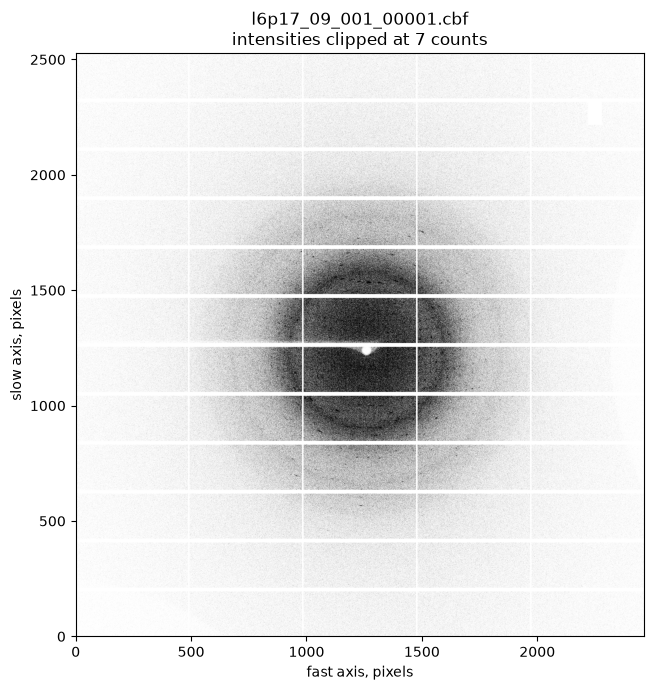

In [7]:
#LOCAL, the following cell depends on this one.

import matplotlib.pyplot as plt
import numpy as np
from dxtbx.model.experiment_list import ExperimentListFactory

expts_one = ExperimentListFactory.from_filenames([str(frames[0])])
imageset = expts_one.imagesets()[0]
raw = imageset.get_raw_data(0)[0].as_numpy_array()

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(np.clip(raw, 0, 7), cmap="Greys", origin="lower")
ax.set_title(f"{frames[0].name}\nintensities clipped at 7 counts")
ax.set_xlabel("fast axis, pixels")
ax.set_ylabel("slow axis, pixels")
plt.tight_layout()
plt.show()

In [11]:
# LOCAL

# The same frame described by its models rather than its pixels.
beam = imageset.get_beam()
det = imageset.get_detector()[0]
gon = imageset.get_goniometer()
scan = imageset.get_scan()

print("Wavelength      :", round(beam.get_wavelength(), 6), "angstroms")
print("Detector origin :", tuple(round(v, 3) for v in det.get_origin()), "mm")
print("Pixel size      :", det.get_pixel_size(), "mm")
print("Image size      :", det.get_image_size(), "pixels")
print("Distance        :", round(det.get_distance(), 2), "mm")
print("Rotation axis   :", gon.get_rotation_axis())
print("Oscillation     :", scan.get_oscillation(), "degrees")

Wavelength      : 1.0332 angstroms
Detector origin : (-216.548, 213.28, -200.0) mm
Pixel size      : (0.17200000000000001, 0.17200000000000001) mm
Image size      : (2463, 2527) pixels
Distance        : 200.0 mm
Rotation axis   : (1.0, 0.0, 0.0)
Oscillation     : (0.0, 0.2) degrees


## 4. `dials.import`

The first dispatcher reads the headers of every frame and writes `imported.expt`, a JSON
file holding the beam, detector, goniometer, and scan models. No pixel data is copied.

In [12]:
# LOCAL
!dials.import frames/{STEM}_*.cbf output.experiments=imported.expt

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
100%|█████████████████████████████████████████| 60/60 [00:00<00:00, 894.47it/s]
The following parameters have been modified:

input {
  experiments = <image files>
}

--------------------------------------------------------------------------------
  format: <class 'dxtbx.format.FormatCBFMiniPilatus.FormatCBFMiniPilatus'>
  template: /Users/blaine/3285CCinJNiucr26/demos/mpro_dials/frames/l6p17_09_001_#####.cbf:1:60
  num images: 60
  sequences:
    still:    0
    sweep:    1
  num stills: 0
--------------------------------------------------------------------------------
Writing experiments to imported.expt


In [13]:
# LOCAL
# imported.expt is plain JSON. Show students that nothing is hidden.
import json

with open("imported.expt") as fh:
    doc = json.load(fh)
print("Top-level keys :", list(doc.keys()))
print()
print(json.dumps(doc["beam"], indent=2)[:600])

Top-level keys : ['__id__', 'experiment', 'history', 'imageset', 'beam', 'detector', 'goniometer', 'scan', 'crystal', 'profile', 'scaling_model']

[
  {
    "__id__": "monochromatic",
    "direction": [
      0.0,
      0.0,
      1.0
    ],
    "wavelength": 1.0332,
    "divergence": 0.0,
    "sigma_divergence": 0.0,
    "polarization_normal": [
      0.0,
      1.0,
      0.0
    ],
    "polarization_fraction": 0.999,
    "flux": 0.0,
    "transmission": 1.0,
    "probe": "x-ray",
    "sample_to_source_distance": 0.0
  }
]


## 5. `dials.find_spots`

Spot finding applies a dispersion threshold to every frame and records the position and
intensity of each strong reflection. The result is `strong.refl`, a reflection table.

This is the first place where a parameter change produces a visible difference, so it is
the first good place to stop and let a student change something.

In [14]:
# LOCAL

!dials.find_spots imported.expt output.reflections=strong.refl nproc=2

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:

spotfinder {
  mp {
    nproc = 2
  }
}
input {
  experiments = imported.expt
}

Setting spotfinder.filter.min_spot_size=3
Configuring spot finder from input parameters
--------------------------------------------------------------------------------
Finding strong spots in imageset 0
--------------------------------------------------------------------------------

Finding spots in image 1 to 60...
Setting chunksize=30
Extracting strong pixels from images
 Using multiprocessing with 2 parallel job(s)

Found 1070 strong pixels on image 1
Found 1006 strong pixels on image 2
Found 1030 strong pixels on image 3
Found 1052 strong pixels on image 4
Found 1038 strong pixels on image 5
Found 1058 strong pixels on image 6
Found 1056 strong pixels on image 7
Found 1081 strong pixels on image 8
Found 991 strong pixels on image 9
Found 1077 strong pixels on image 1

In [15]:
# LOCAL

# A reflection table behaves like a column store. Print its shape and columns.
from dials.array_family import flex

strong = flex.reflection_table.from_file("strong.refl")
print("Strong spots :", strong.size())
print("Columns      :")
for name in sorted(strong.keys()):
    print("   ", name)

Strong spots : 1566
Columns      :
    bbox
    flags
    id
    intensity.sum.value
    intensity.sum.variance
    n_signal
    panel
    shoebox
    xyzobs.px.value
    xyzobs.px.variance


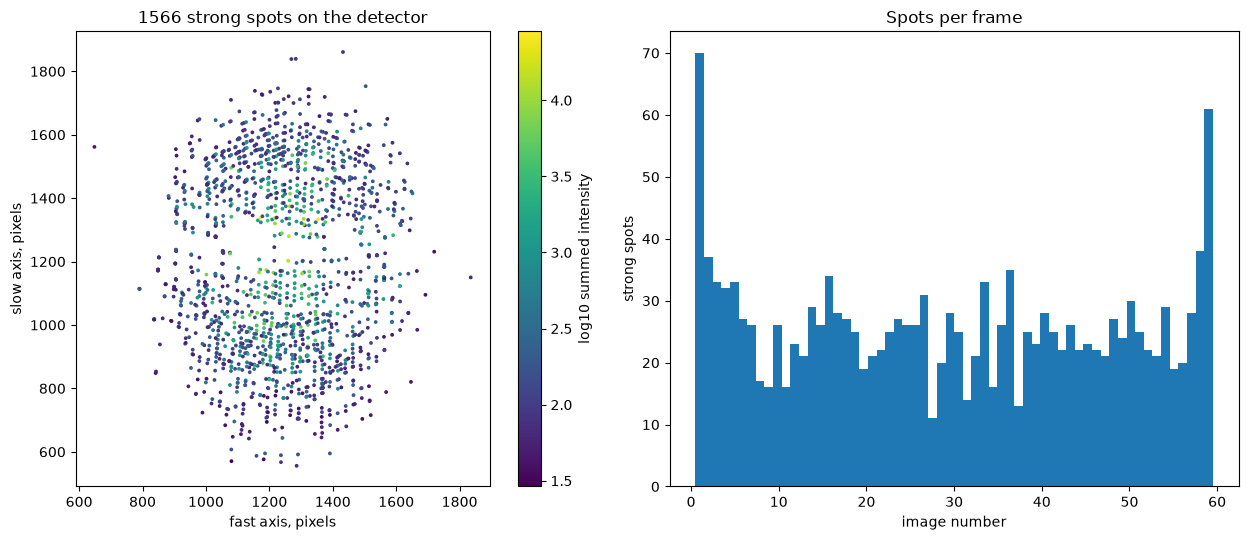

In [16]:
# Where did the spots land on the detector, and how do they spread through the sweep?
xyz = strong["xyzobs.px.value"].as_double().as_numpy_array().reshape(-1, 3)
intensity = strong["intensity.sum.value"].as_numpy_array()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

sc = ax1.scatter(xyz[:, 0], xyz[:, 1], c=np.log10(np.clip(intensity, 1, None)), s=3, cmap="viridis")
ax1.set_aspect("equal")
ax1.set_xlabel("fast axis, pixels")
ax1.set_ylabel("slow axis, pixels")
ax1.set_title(f"{strong.size()} strong spots on the detector")
fig.colorbar(sc, ax=ax1, label="log10 summed intensity")

ax2.hist(xyz[:, 2], bins=N_FRAMES)
ax2.set_xlabel("image number")
ax2.set_ylabel("strong spots")
ax2.set_title("Spots per frame")
plt.tight_layout()
plt.show()

**Try this in class.** Rerun spot finding with `spotfinder.threshold.dispersion.sigma_strong=5`
and compare the spot count. A higher threshold finds fewer, cleaner spots. Ask the students
which direction helps indexing and which direction helps integration.

## 6. Visualizing reciprocal space

Spot finding gives positions on a detector. Mapping those positions into reciprocal space
turns them into a lattice, and the lattice is the thing indexing actually works on. Showing
the lattice before indexing runs makes the next step feel inevitable rather than magical.

In [17]:
from dxtbx.model.experiment_list import ExperimentListFactory

expts = ExperimentListFactory.from_json_file("imported.expt", check_format=False)

mapped = flex.reflection_table.from_file("strong.refl")
mapped.centroid_px_to_mm(expts)
mapped.map_centroids_to_reciprocal_space(expts)
rlp = mapped["rlp"].as_double().as_numpy_array().reshape(-1, 3)
print("Reciprocal lattice points :", rlp.shape)

Reciprocal lattice points : (1566, 3)


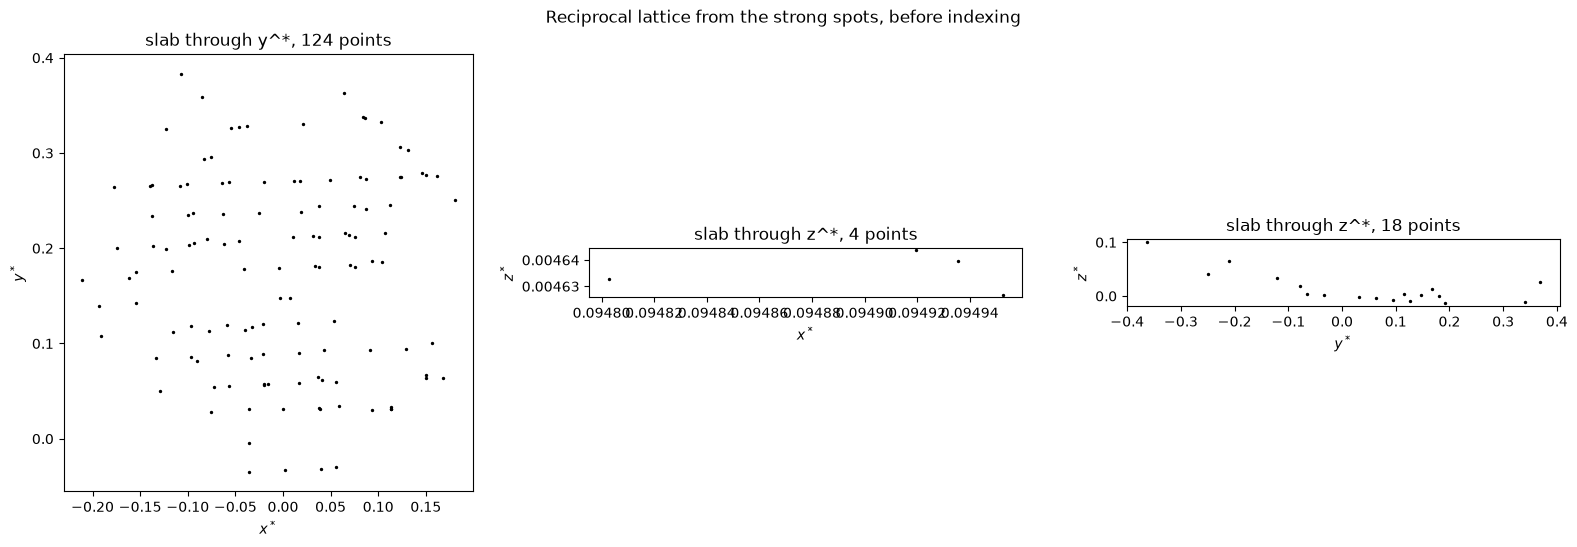

In [18]:
# Three orthogonal slabs through the reciprocal lattice.
fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
slab = 0.004  # thickness of the slab in reciprocal angstroms
pairs = [(0, 1, 2, "$x^*$", "$y^*$"), (0, 2, 1, "$x^*$", "$z^*$"), (1, 2, 0, "$y^*$", "$z^*$")]

for ax, (i, j, k, xl, yl) in zip(axes, pairs):
    keep = np.abs(rlp[:, k]) < slab
    ax.scatter(rlp[keep, i], rlp[keep, j], s=2, c="k")
    ax.set_aspect("equal")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"slab through {yl.strip('$')}, {keep.sum()} points")

fig.suptitle("Reciprocal lattice from the strong spots, before indexing")
plt.tight_layout()
plt.show()

The rows of dots are the reciprocal lattice. Indexing is the search for the three vectors
that generate them.

## 7. `dials.index`

Indexing finds the orientation matrix and the unit cell. The default one-dimensional
Fourier transform method searches for periodic spacing along many candidate directions.

In [19]:
# LOCAL slow, long output

!dials.index imported.expt strong.refl output.experiments=indexed.expt output.reflections=indexed.refl

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:

input {
  experiments = imported.expt
  reflections = strong.refl
}

Found max_cell: 113.5 Angstrom
Setting d_min: 2.22
FFT gridding: (256,256,256)
Number of centroids used: 1464
Candidate solutions:
+------------------------------------+----------+----------------+------------+-------------+-------------------+-----------+-----------------+-----------------+
| unit_cell                          |   volume |   volume score |   #indexed |   % indexed |   % indexed score |   rmsd_xy |   rmsd_xy score |   overall score |
|------------------------------------+----------+----------------+------------+-------------+-------------------+-----------+-----------------+-----------------|
| 44.82 53.43 61.58 115.0 101.4 90.5 |   130329 |           0.01 |        926 |          60 |              0    |      0.31 |            0    |            0.01 |
| 45.67 53.34 61

In [20]:
# Pull the crystal model out of the experiment list rather than reading it off the log.
indexed_expts = ExperimentListFactory.from_json_file("indexed.expt", check_format=False)
xtal = indexed_expts[0].crystal

print("Space group   :", xtal.get_space_group().info())
uc = xtal.get_unit_cell().parameters()
print("Unit cell     : a={:.2f} b={:.2f} c={:.2f} alpha={:.1f} beta={:.1f} gamma={:.1f}".format(*uc))
print("Volume        : {:.0f} cubic angstroms".format(xtal.get_unit_cell().volume()))
print()
print("A matrix      :")
print(np.array(xtal.get_A()).reshape(3, 3))

Space group   : P 1
Unit cell     : a=44.56 b=53.09 c=62.52 alpha=115.3 beta=101.7 gamma=89.9
Volume        : 130358 cubic angstroms

A matrix      :
[[-0.00119264  0.01865933 -0.00030342]
 [ 0.02007902  0.00699291  0.01214504]
 [ 0.01120075 -0.00640228 -0.01348005]]


In [21]:
# How many of the strong spots picked up an index?
indexed = flex.reflection_table.from_file("indexed.refl")
flags = indexed.get_flags(indexed.flags.indexed)
print(f"{flags.count(True)} of {indexed.size()} reflections were indexed "
      f"({100 * flags.count(True) / indexed.size():.1f} percent)")

936 of 1566 reflections were indexed (59.8 percent)


**Discussion point.** The deposited structure 6YNQ is in space group C2. `dials.index`
reports the lattice it can defend from the geometry alone, which is usually the primitive
triclinic setting or the highest metric symmetry consistent with the cell. Symmetry is
determined later, from the intensities, by `dials.symmetry`. Separating the two steps is
worth a minute of class time, because students routinely conflate them.

## 8. `dials.refine`

Refinement polishes the experimental geometry against every indexed reflection at once.
The detector position, the beam direction, and the crystal orientation all move.

In [22]:
!dials.refine indexed.expt indexed.refl output.experiments=refined.expt output.reflections=refined.refl

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:

input {
  experiments = indexed.expt
  reflections = indexed.refl
}

Configuring refiner
Setting outlier.nproc=16

Summary statistics for 924 observations matched to predictions:
+-------------------+--------+----------+------------+---------+-------+
|                   |    Min |       Q1 |        Med |      Q3 |   Max |
|-------------------+--------+----------+------------+---------+-------|
| Xc - Xo (mm)      | -1.098 |  -0.1194 |  -0.002514 |   0.128 | 1.176 |
| Yc - Yo (mm)      | -1.462 | -0.05739 | -0.0005925 | 0.05263 | 1.401 |
| Phic - Phio (deg) | -4.271 | -0.07267 | -0.0009854 | 0.08413 |  3.49 |
| X weights         |  264.2 |    361.1 |      381.2 |   393.8 | 405.6 |
| Y weights         |  345.4 |    393.3 |        400 |   403.8 | 405.6 |
| Phi weights       |  268.3 |    293.9 |      298.4 |     300 |   300 |
+-------------------+-------

In [23]:
# Compare the cell before and after refinement.
refined_expts = ExperimentListFactory.from_json_file("refined.expt", check_format=False)
before = indexed_expts[0].crystal.get_unit_cell().parameters()
after = refined_expts[0].crystal.get_unit_cell().parameters()

print(f"{'':10s}{'indexed':>12s}{'refined':>12s}{'change':>12s}")
for label, b, a in zip(["a", "b", "c", "alpha", "beta", "gamma"], before, after):
    print(f"{label:10s}{b:12.4f}{a:12.4f}{a - b:12.4f}")

               indexed     refined      change
a              44.5591     44.5395     -0.0196
b              53.0884     53.0721     -0.0163
c              62.5221     62.5305      0.0085
alpha         115.2855    115.3572      0.0717
beta          101.6668    101.6689      0.0022
gamma          89.9416     89.8730     -0.0686


## 9. `dials.integrate` and `dials.scale`

Integration measures the intensity of every predicted reflection, including the weak ones
that spot finding skipped. Scaling puts the measurements on a common scale and merges them.

Integration is the slowest workflow step. On two Colab cores a twelve-degree wedge takes a
few minutes.

In [24]:
!dials.integrate refined.expt refined.refl output.experiments=integrated.expt output.reflections=integrated.refl nproc=2

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:
integration {
  mp {
    nproc = 2
  }
}
input {
  experiments = refined.expt
  reflections = refined.refl
}



Experiments

Models for experiment 0

Beam:
    probe: x-ray
    wavelength: 1.0332
    sample to source direction : {-0.0121746,-0,0.999926}
    divergence: 0
    sigma divergence: 0
    polarization normal: {0,1,0}
    polarization fraction: 0.999
    flux: 0
    transmission: 1
    sample to source distance: 0

Detector:
Panel:
  name: Panel
  type: SENSOR_PAD
  identifier: 
  pixel_size:{0.172,0.172}
  image_size: {2463,2527}
  trusted_range: {0,75337}
  thickness: 0.32
  material: Si
  mu: 4.63023
  gain: 1
  pedestal: 0
  fast_axis: {0.99908,0.0417855,0.00965484}
  slow_axis: {0.0418058,-0.999124,-0.00191109}
  origin: {-223.127,204.248,-200.682}
  distance: 199.01
  pixel to millimeter strategy: ParallaxCorrectedPxMmStrategy
    mu: 4.6

In [25]:
!dials.symmetry integrated.expt integrated.refl output.experiments=symmetrized.expt output.reflections=symmetrized.refl

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:

input {
  experiments = integrated.expt
  reflections = integrated.refl
}


Performing Laue group analysis

Mapping all input cells to a common minimum cell
Filtering reflections for dataset 0
Read 19626 predicted reflections
Selected 15075 reflections integrated by profile and summation methods
Removed 2 reflections below partiality threshold
Removed 14 intensity.sum.value reflections with I/Sig(I) < -5
Removed 1 intensity.prf.value reflections with I/Sig(I) < -5
A round of outlier rejection has been performed, 
0 outliers have been identified. 

Patterson group: C 1 2/m 1 (-z,x+y,2*x)

--------------------------------------------------------------------------------

Normalising intensities for dataset 1

ML estimate of overall B_cart value:
  -10.10,  0.63, 16.11
         10.34, -0.66
                -6.27
ML estimate of  -log of scale factor:
  -2.5

In [26]:
!dials.scale symmetrized.expt symmetrized.refl output.html=scaling.html output.unmerged_mtz=scaled_unmerged.mtz output.merged_mtz=scaled.mtz

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
DIALS 3.30
The following parameters have been modified:
output {
  html = "scaling.html"
  unmerged_mtz = "scaled_unmerged.mtz"
  merged_mtz = "scaled.mtz"
}
input {
  experiments = symmetrized.expt
  reflections = symmetrized.refl
}

Checking for the existence of a reflection table 
containing multiple datasets 

Found 1 reflection tables & 1 experiments in total.

Dataset ids are: 0 

Set scaling_options.full_matrix=True
Set reflection_selection.method=quasi_random
Space group being used during scaling is I 1 2 1
Set small scale cutoff to 0.001

Scaling models have been initialised for all experiments.


The experiment id for this dataset is 0.
The scaling model type being applied is physical. 

Applying filter of min_isigi > -5.0, partiality > 0.25
Read 19626 predicted reflections
Selected 19626 reflections integrated by profile or summation methods
Removed 1950 reflections below partiality threshold
Remo

## 10. Read the merged data back without leaving Python

The point of ending here is that the MTZ file is not a terminus. It is an input to the
next notebook, and it is a pandas data frame away from any analysis a student wants to try.

In [27]:
import gemmi

mtz = gemmi.read_mtz_file("scaled.mtz")
print("Space group :", mtz.spacegroup.hm)
print("Cell        :", mtz.cell)
print("Resolution  : {:.2f} to {:.2f} angstroms".format(mtz.resolution_low(), mtz.resolution_high()))
print("Columns     :")
for col in mtz.columns:
    print(f"    {col.label:12s} {col.type}")

Space group : I 1 2 1
Cell        : <gemmi.UnitCell(44.5395, 53.0721, 111.862, 90, 99.9679, 90)>
Resolution  : 30.92 to 1.09 angstroms
Columns     :
    H            H
    K            H
    L            H
    FreeR_flag   I
    IMEAN        J
    SIGIMEAN     Q
    N            I
    F            F
    SIGF         Q
    I(+)         K
    SIGI(+)      M
    I(-)         K
    SIGI(-)      M
    N(+)         I
    N(-)         I
    F(+)         G
    SIGF(+)      L
    F(-)         G
    SIGF(-)      L
    DANO         D
    SIGDANO      Q


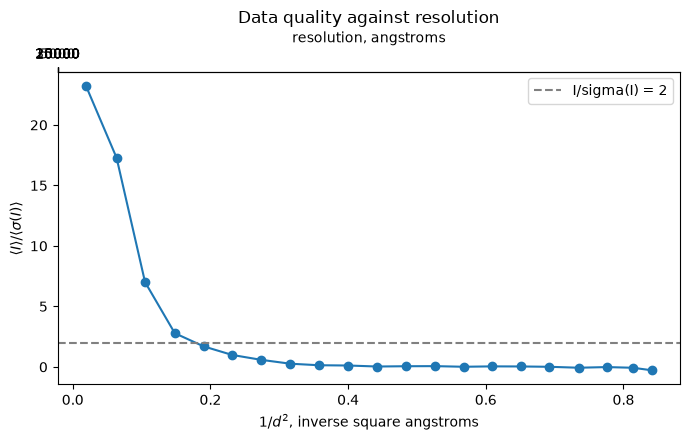

In [29]:
# Signal-to-noise against resolution, computed in twenty shells.
import reciprocalspaceship as rs

ds = rs.read_mtz("scaled.mtz").compute_dHKL()
ds["invd2"] = 1.0 / ds["dHKL"] ** 2
ds["shell"] = np.digitize(ds["invd2"], np.linspace(ds["invd2"].min(), ds["invd2"].max(), 21))

icol = "IMEAN" if "IMEAN" in ds.columns else "I"
scol = "SIGIMEAN" if "SIGIMEAN" in ds.columns else "SIGI"
agg = ds.groupby("shell").agg(I=(icol, "mean"), SIG=(scol, "mean"), d=("dHKL", "mean"))
agg["IsigI"] = agg["I"] / agg["SIG"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(1.0 / agg["d"] ** 2, agg["IsigI"], marker="o")
ax.axhline(2.0, ls="--", c="grey", label="I/sigma(I) = 2")
ax.set_xlabel(r"$1/d^2$, inverse square angstroms")
ax.set_ylabel(r"$\langle I \rangle / \langle \sigma(I) \rangle$")
ax.set_title("Data quality against resolution")
ax.legend()

# Label the top axis in angstroms, because that is how crystallographers think.
sec = ax.secondary_xaxis("top", functions=(lambda s: np.sqrt(1 / np.maximum(s, 1e-9)),
                                           lambda d: 1 / np.maximum(d, 1e-9) ** 2))
sec.set_xlabel("resolution, angstroms")
plt.tight_layout()
plt.show()

## I2 is non-standard and how to deal with it

I2 is a non-standard *setting* of the standard space group C2 (No. 5, C121). 
    Both describe the same monoclinic lattice with the same symmetry operators; they differ only in how you label the unit-cell axes. In the standard C2 setting the lattice is C-centered on the ab face. In the I2 setting it is body-centered. You can convert one to the other by rotating the choice of a and c around the unique monoclinic b axis.

Why DIALS often lands on I2 instead of C2 for a dataset that has a valid C2 description. When DIALS indexes and refines a monoclinic cell, it picks the setting that makes the β angle closest to 90°. The C2 setting can produce β values well above 100° for the same lattice. The I2 setting for the same crystal often gives β near 90°, which is numerically better conditioned during refinement and easier to read. Both are geometrically identical.

Concretely for Mpro. Mpro crystallizes in a monoclinic lattice with C2 symmetry. Every deposited Mpro structure in the PDB uses C121. The reason your DIALS run reports I2 is that DIALS chose the alternate setting whose β came in near 90° rather than near 100° or 105°.

Why this matters downstream. Some tools accept both settings and do not care. Some tools insist on the standard C2 setting because the international tables and most reference files use it. Phaser, Refmac, and phenix.refine all accept either. But if you compare your unit cell against a deposited PDB header, you need to be looking at the same setting or the numbers will disagree.

How to convert to C2 if you want to match the PDB convention. DIALS ships a reindex tool:

```bash
dials.reindex scaled.expt scaled.refl space_group="C 1 2 1"
```

That rewrites the reflections in the standard setting and also updates the experiment file so `dials.export` produces an MTZ whose header reads C121.

Alternatively, from a merged MTZ, use pointless (CCP4) or gemmi:

```bash
pointless HKLIN scaled.mtz HKLOUT scaled_C2.mtz spacegroup C121
```

or in Python:

```python
import gemmi
mtz = gemmi.read_mtz_file("scaled.mtz")
mtz.spacegroup = gemmi.SpaceGroup("C 1 2 1")
# You will also need to re-express the cell in the C2 basis; gemmi will
# apply the change-of-basis if you use gemmi.reindex().
```

For the lecture, this is a great teaching moment about the difference between a space group (an abstract set of symmetries) and a *setting* (a concrete choice of axes). The lattice is the crystal. The setting is just how humans wrote it down.

## 11. The DIALS report

`dials.report` collects every diagnostic plot into one HTML file. Download it and open it
in a browser tab beside the notebook.

In [30]:
!dials.report symmetrized.expt symmetrized.refl output.html=dials.report.html

DIALS (2018) Acta Cryst. D74, 85-97. https://doi.org/10.1107/S2059798317017235
The following parameters have been modified:

input {
  experiments = symmetrized.expt
  reflections = symmetrized.refl
}

Analysing strong spots
 Selected 655 strong reflections...........................................0.00s
Analysing reflection centroids
 Removing 6442 partial reflections
 Selected 11853 summation-integrated reflections...........................0.00s
 Analysing centroid differences with I/Sigma > 10
 Analysing centroid differences in x/y with I/Sigma > 10
 Analysing centroid differences in z with I/Sigma > 10
 Analysing centroid differences vs phi with I/Sigma > 10
Analysing reflection intensities
 Removing 8472 reflections with intensity <= 0
 Selected 11154 integrated reflections.....................................0.00s
 Analysing distribution of I/Sigma
 Analysing distribution of I/Sigma vs xy
 Analysing distribution of I/Sigma vs xy
 Analysing distribution of I/Sigma vs z
 Analysing

In [31]:
if IN_COLAB:
    from google.colab import files

    files.download("dials.report.html")
    files.download("scaled.mtz")
else:
    print("Report written to", (WORK / "dials.report.html").resolve())

Report written to /Users/blaine/3285CCinJNiucr26/demos/mpro_dials/dials.report.html


## Exercises

1. Rerun spot finding with `sigma_strong=5` and again with `sigma_strong=2`. Plot the spot
   count against the threshold. Which setting gives the best indexing rate?
2. Cut the wedge in half by importing only the first thirty frames. Does indexing still
   succeed? What happens to completeness after scaling?
3. Force a wrong lattice with `dials.index space_group=P1` and compare the refined cell
   against the default run.
4. Use `mapped["rlp"]` to compute the resolution of every strong spot, then plot the
   distribution. Compare it against the `resolution: 1.304257A` claim in the Zenodo header.

## What to carry forward

`scaled.mtz` from this notebook is the input to Demo 3, the molecular replacement workflow.
Save it to Google Drive if you plan to run these demonstrations in sequence.

In [ ]:
# Keep the merged data after the virtual machine shuts down.
# Set SAVE_TO_DRIVE to True the first time you run this in class.
SAVE_TO_DRIVE = False

if IN_COLAB and SAVE_TO_DRIVE:
    import shutil

    from google.colab import drive

    drive.mount("/content/drive")
    dest = pathlib.Path("/content/drive/MyDrive/iucr26_demos")
    dest.mkdir(parents=True, exist_ok=True)
    for name in ["scaled.mtz", "scaled_unmerged.mtz"]:
        shutil.copy(name, dest / name)
        print("Copied", name, "to", dest)

## Sources

* DIALS documentation. https://dials.github.io Winter *et al.* Acta Cryst. Sect. D 74, 86-97.
* Zenodo record 3752540. https://doi.org/10.5281/zenodo.3752540
* PDB entry 6YNQ. https://www.rcsb.org/structure/6YNQ.  Gunther *et al.* (2021) Science 372, 642-646.